# Practical Workshop 2 — Data Loading in PyTorch

In Workshop 2 we saw how to use PyTorch's own tools to abstract the model, the loss, and the optimiser. This reduced the amount of hand-written code we needed to introduce. However, an important feature we didn't abstract was the data. Up until know, we have kept a single tensor `X` in memory and fed it to the model at once.
 
While this works for a toy problem, it will not work once your data is too big for memory, needs shuffling and batching every epoch, or needs preprocessing on the fly. This is what PyTorch's `Dataset` and `DataLoader` are for.

By the end of this notebook you will be able to:

1. Look at your data before modelling it.
2. Split into train / validation / test sets the way you would in practice.
3. Wrap data in a `Dataset` and iterate batches with a `DataLoader`.
4. Write custom datasets for tabular and image data.
5. Apply transforms for preprocessing and augmentation.
6. Use `num_workers`, shuffling, and the other `DataLoader` flags, and understand *why* each helps.
7. Handle datasets larger than memory mainly via memory-mapping.

## Part 0 — Setup

In [35]:
import os, time, glob
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, TensorDataset, IterableDataset

torch.manual_seed(0)
np.random.seed(0)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("PyTorch", torch.__version__, ", device:", device)

WORK = "pw2_data"
os.makedirs(WORK, exist_ok=True)

PyTorch 2.5.1 , device: cuda


## Part 1 — `Dataset` and `DataLoader`

- A `Dataset` is a collection of data samples you can index. `dataset[i]` returns one sample.
- A `DataLoader` wraps a `Dataset` and hands you batches, groups of data samples, optionally shuffled.

`TensorDataset` is a built-in `Dataset` that pairs up tensors.

In [36]:
# Generate a synethetic dataset with  10 fake samples, each with 3 features and one binary label.
X_toy = torch.randn(10, 3)
y_toy = torch.randint(0, 2, (10,))

# Create a TensorDataset from the synthetic data
toy_ds = TensorDataset(X_toy, y_toy) 

print("len(toy_ds):", len(toy_ds))

features, label = toy_ds[0]

print("toy_ds[0] -> features", features.tolist(), "| label", label.item())

len(toy_ds): 10
toy_ds[0] -> features [-1.1258398294448853, -1.152360200881958, -0.2505785822868347] | label 1


Now with our dataset generated, we can wrap it in a `DataLoader` to generate batches automatically. Let's have that the data is first shuffled before batching.

In [3]:
toy_loader = DataLoader(toy_ds, batch_size=4, shuffle=True)

for batch_idx, (xb, yb) in enumerate(toy_loader):
    print(f"batch {batch_idx}: x {tuple(xb.shape)}, y {tuple(yb.shape)}")

print("\nbatches per pass:", len(toy_loader))

batch 0: x (4, 3), y (4,)
batch 1: x (4, 3), y (4,)
batch 2: x (2, 3), y (2,)

batches per pass: 3


In summary: `Dataset` defines how to get a single sample, and `DataLoader` turns these into batches.

## Part 2 — Loading Some Data

Rather than using only synethic data, we will now use the Breast Cancer Wisconsin dataset which comes with scikit-learn. The dataset consists of 569 patients, 30
real-valued features computed from cell-nucleus images, and a binary label (malignant vs benign).

In [37]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X_all = data.data.astype("float32")        # Size (569, 30)
y_all = data.target.astype("int64")        # Size (569,) with binary labels 0 = malignant, 1 = benign
feat_names = data.feature_names

print("X:", X_all.shape, "| y:", y_all.shape)
print("classes:", dict(zip(data.target_names, np.bincount(y_all))))

X: (569, 30) | y: (569,)
classes: {np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}


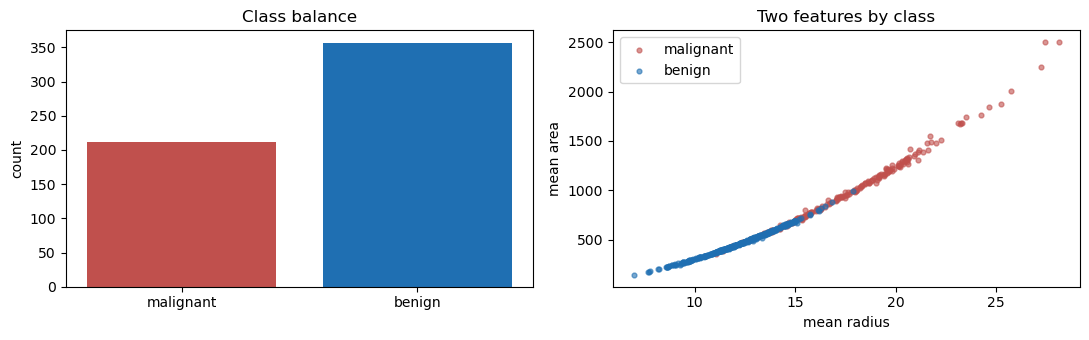

In [38]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))

# Class balance
counts = np.bincount(y_all)
ax[0].bar(data.target_names, counts, color=["#c0504d", "#1f6fb2"])
ax[0].set_title("Class balance")
ax[0].set_ylabel("count")

# Two features, coloured by class
f1, f2 = 0, 3   # "mean radius" vs "mean area"
for cls, colour, name in [(0, "#c0504d", data.target_names[0]),
                          (1, "#1f6fb2", data.target_names[1])]:
    m = y_all == cls
    ax[1].scatter(X_all[m, f1], X_all[m, f2], s=12, alpha=0.6, c=colour, label=name)
ax[1].set_xlabel(feat_names[f1]); ax[1].set_ylabel(feat_names[f2])
ax[1].set_title("Two features by class"); ax[1].legend()
plt.tight_layout(); plt.show()

The classes are imbalanced, with ~63% benign, and these two features already separate them fairly well.

Two conclusions to carry forward from these figures: 
1. The class imbalance means we should split our data in a stratified way
2. The features live on very different scales (radius ~10–30, area ~140–2500) so we'll need to normalise before passing to our model.

## Part 3 — Train / validation / test splits

Before passing data to a `Dataset` or `DataLoader`, we first should decide how to split the data. The standard three-way split:

- Train — the model learns from this.
- Validation — used during training to tune hyperparameters.
- Test — used once at the very end to estimate real-world performance.

We use scikit-learn's `train_test_split`.


In [41]:
from sklearn.model_selection import train_test_split

training_test_size = 0.2
validation_test_size = 0.25

# First split off the test set 20%, stratified using y_all to keep class balance.
X_tmp, X_test, y_tmp, y_test = train_test_split(X_all, y_all, test_size=training_test_size, stratify=y_all, random_state=0)

# Then split the remainder into train (75%) and validation (25%)
X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size=validation_test_size, stratify=y_tmp, random_state=0)

for name, y in [("train", y_train), ("val", y_val), ("test", y_test)]:
    frac = np.bincount(y) / len(y)
    print(f"{name:5s}: {len(y):3d} samples | class fractions {frac.round(2)}")

train: 341 samples | class fractions [0.37 0.63]
val  : 114 samples | class fractions [0.38 0.62]
test : 114 samples | class fractions [0.37 0.63]


Notice the class fractions stay roughly 0.37 / 0.63 in every split. This is a result of stratification! We are ensuring that the class imbalance in each data split resembles the class fractions in the combined dataset.

Next, we need to normalise our data such that the features live on similar scales. To do so, we compute the mean and standard deviation on the training set only, and
apply them to all three splits. If we also used the mean and standard deviation from the validation and test datasets, this would leak information from the data the model shouldn't see, and erroneously improve the model's performance on these datasets.

In [7]:
def standardise(X, mean, std):
    return (X - mean) / std

In [42]:
mean = X_train.mean(axis=0)
std  = X_train.std(axis=0) + 1e-8 # Add a small epsilon to avoid division by zero

X_train = standardise(X_train, mean, std)
X_val   = standardise(X_val,   mean, std)
X_test  = standardise(X_test,  mean, std)

## Part 4 — A custom `Dataset` for tabular data

To define a custom `Dataset`, you only need `__len__` to provide the length, and `__getitem__` to extract an element of the dataset. 

In [43]:
class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.x = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, i):
        return self.x[i], self.y[i]                      # one (features, label) pair

# Instantiate a custom dataset for each data split.
train_ds = TabularDataset(X_train, y_train)
val_ds   = TabularDataset(X_val,   y_val)
test_ds  = TabularDataset(X_test,  y_test)

print("len(train_ds):", len(train_ds))
x0, y0 = train_ds[0]
print("one sample -> features", x0.shape, "| label", y0.item())

len(train_ds): 341
one sample -> features torch.Size([30]) | label 1


Then, with a dataset for each data split, we create seperate dataloaders. We will shuffle the training dataloader, but keep the validation and testing dataloaders fixed.

In [44]:
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False)

xb, yb = next(iter(train_loader))
print("one batch:", xb.shape, yb.shape)
print("train batches per epoch:", len(train_loader))

one batch: torch.Size([32, 30]) torch.Size([32])
train batches per epoch: 11


### 4.1 — A real training loop using the splits and abstracted dataloader

We can now take our abstracted dataset, and add it to our abstracted training loop. We train on `train_loader`, check the performance on `val_loader` at the end of each epoch, and only at the end of training, report performance on `test_loader`.

In [45]:
def evaluate_model(model, loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            predictions = model(xb).argmax(1)
            correct_predictions = (predictions == yb).sum().item()
            correct += correct_predictions
            total   += len(yb)
    return correct / total

In [46]:
model   = nn.Sequential(nn.Linear(30, 32), 
                        nn.ReLU(), 
                        nn.Linear(32, 2)).to(device)
loss_fn = nn.CrossEntropyLoss()
opt     = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(15):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = loss_fn(model(xb), yb)
        loss.backward()
        opt.step()

    if epoch % 3 == 0:
        print(f"epoch {epoch:2d} | val acc {evaluate_model(model, val_loader):.3f}")

print(f"\nFinal performance on test set: {evaluate_model(model, test_loader):.3f}")

epoch  0 | val acc 0.860
epoch  3 | val acc 0.956
epoch  6 | val acc 0.974
epoch  9 | val acc 0.974
epoch 12 | val acc 0.974

Final performance on test set: 0.956


## Part 5 — A custom `Dataset` for images

Part 4 introduced how to create a custom Pytorch dataset when dealing with tabular numerical data. We will now take a look at how to create a dataset when our data are images. We'll use scikit-learn's digits dataset, consisting of 1797 handwritten digits as 8×8 grayscale images. The dataset jas been included inside `pw2_data/digits`


In [47]:
from PIL import Image

img_root = os.path.join(WORK, "digits")
paths   = glob.glob(os.path.join(img_root, "*", "*.png"))


In [49]:
def label_from_path(p):
    return int(os.path.basename(os.path.dirname(p)))

class DigitImageDataset(Dataset):
    def __init__(self, paths, transform=None):
        self.paths = sorted(paths)
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        path = self.paths[i]
        img  = Image.open(path)
        y    = label_from_path(path)
        if self.transform:
            img = self.transform(img)
        return img, y

raw = DigitImageDataset(paths)
img, lab = raw[0]
print("type:", type(img).__name__, "| size:", img.size, "| label:", lab)

type: PngImageFile | size: (8, 8) | label: 0


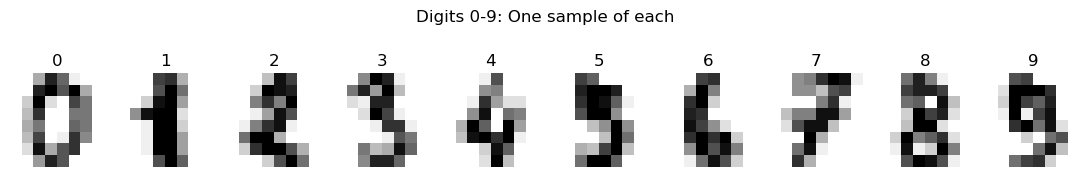

In [50]:
import matplotlib.pyplot as plt
import random

# Find up to 1 example for each digit 0-9
digits_to_show = list(range(10))
samples = []
labels_shown = set()
for idx, p in enumerate(raw.paths):
    lbl = label_from_path(p)
    if lbl in digits_to_show and lbl not in labels_shown:
        img, label = raw[idx]
        samples.append((img, label))
        labels_shown.add(lbl)
    if len(samples) == 10:
        break

fig, axes = plt.subplots(1, 10, figsize=(11, 2))
for i, (img, label) in enumerate(samples):
    axes[i].imshow(img, cmap='gray_r')
    axes[i].set_title(str(label))
    axes[i].axis('off')
plt.suptitle("Digits 0-9: One sample of each")
plt.tight_layout()
plt.show()

Without a transform, our custom `DigitImageDataset` returns a PIL image. A `Dataset` that returns PIL images is no use to a PyTorch model since we need tensors! More importantly, these should be scaled, and augmented. Data augmentation allows you to artificially increase the size of your dataset by creating augmentated copies of samples in your original dataset. This can include, but is not limited to, rotations, zooms, crops, noise, colour, etc,. `torchvision.transforms` gives composable, per-sample transforms that run inside `__getitem__`.

As before, we augment the training set randomly, but keep the validation and test deterministic.


In [51]:
from torchvision import transforms as T

train_tf = T.Compose([T.RandomAffine(degrees=30, translate=(0.2, 0.2)),
                      T.ToTensor(),
                      T.Normalize(mean=[0.5], std=[0.5])])

eval_tf = T.Compose([T.ToTensor(),  # deterministic: no random transform
                     T.Normalize(mean=[0.5], std=[0.5])])

img_dataset = DigitImageDataset(paths, transform=train_tf)

In [52]:
img, lab    = img_dataset[0]
print("now a tensor:", img.shape, img.dtype, f"| range {img.min():.2f}..{img.max():.2f}")

now a tensor: torch.Size([1, 8, 8]) torch.float32 | range -1.00..0.87


Since we used `RandomAffine`, the training augmentations are random, meaning the same index differs between calls.


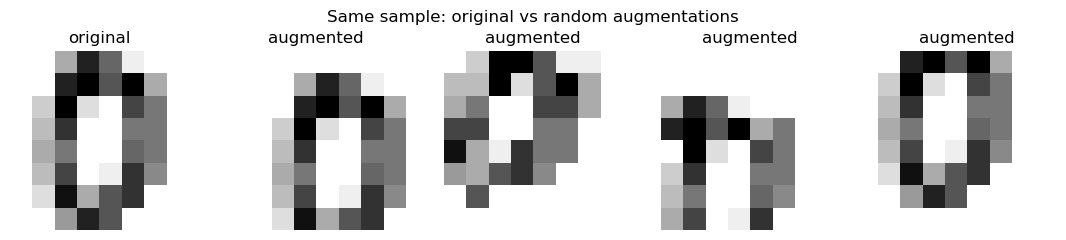

In [53]:
a, b = img_dataset[0][0], img_dataset[0][0]

orig = Image.open(img_dataset.paths[0])
fig, axes = plt.subplots(1, 5, figsize=(11, 2.4))
axes[0].imshow(orig, cmap="gray_r"); axes[0].set_title("original"); axes[0].axis("off")
for ax in axes[1:]:
    t = img_dataset[0][0].squeeze(0)             # (8,8) after a fresh random transform
    ax.imshow(t, cmap="gray_r"); ax.set_title("augmented"); ax.axis("off")
plt.suptitle("Same sample: original vs random augmentations"); plt.tight_layout(); plt.show()

Finally, we can wrap our custom dataset in a `DataLoader`, making it ready for passing into our training loop.

In [55]:
img_loader = DataLoader(img_dataset, batch_size=64, shuffle=True)

xb, yb = next(iter(img_loader))
print("image batch:", xb.shape, "| labels:", yb.shape)   # (64, 1, 8, 8)

image batch: torch.Size([64, 1, 8, 8]) | labels: torch.Size([64])


## Part 6 — `num_workers`, shuffling, and the other flags

The `DataLoader` flags affect both correctness and speed. Here is what each one buys you.


### 6.1 `shuffle` — improves training and enables reproducible evaluation

If the data is ordered (e.g. all class-0 then all class-1), un-shuffled mini-batches are highly correlated and SGD produces biased, noisy gradients. Shuffling makes each batch a fairer random sample of the data. 

Evaluation on the otherhand must be repeatable, so validation and test datasets are never shuffled. We don't want the metric to change from run to run.

In [ ]:
# Generate a synthetic loader over indices 0, 1, ..., 9 to make the order visible.

toy = DataLoader(list(range(10)), batch_size=10, shuffle=True)

print("shuffled epoch 1:", next(iter(toy)).tolist())
print("shuffled epoch 2:", next(iter(toy)).tolist()) 

ordered = DataLoader(list(range(10)), batch_size=10, shuffle=False)
print("unshuffled      :", next(iter(ordered)).tolist()) 

shuffled epoch 1: [9, 1, 6, 4, 2, 0, 3, 7, 5, 8]
shuffled epoch 2: [5, 4, 6, 1, 0, 9, 7, 3, 2, 8]
unshuffled      : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


With shuffle=True, each batch generation produces a random ordering of numbers 0 to 9. With shuffle=False, it will always return the data in the same order it was stored.

### 6.2 `num_workers` — stop the GPU waiting for data

With `num_workers=0`, data is loaded in the same GPU process that runs training. This means, data loading and training compute alternate: the GPU sits idle while the next batch is read and preprocessed. With `num_workers>0`, subprocesses load upcoming batches in parallel with GPU compute, so a batch is ready the moment the GPU needs it. It matters most when `__getitem__` is slow, for instance if you need to read files, decode images, augment images, etc.


In [57]:
class SlowDataset(Dataset):
    def __init__(self, n=256): self.n = n
    def __len__(self):         return self.n
    def __getitem__(self, i):
        "Simulate a slow ~5 ms to load data"
        time.sleep(0.005)
        return torch.tensor([float(i)]), i

def time_loader(num_workers):
    dl = DataLoader(SlowDataset(256), batch_size=32, num_workers=num_workers)
    t0 = time.time()
    for _ in dl: pass
    return time.time() - t0

t0 = time_loader(0)
print(f"num_workers=0 : {t0:.2f}s  (GPU would wait this long for data)")

t4 = time_loader(4)
print(f"num_workers=4 : {t4:.2f}s  ->  {t0/t4:.1f}x faster")

num_workers=0 : 1.31s  (GPU would wait this long for data)
num_workers=4 : 0.44s  ->  3.0x faster


How many workers should I use? Too few workers and the GPU sits idle, while too many workes and you waste RAM and CPU on contention. A common starting point is about 4 × (number of GPUs), then evaluate. Though, this is really a thing to consider on machines with heavy I/O during training.

### 6.3 `pin_memory` — faster CPU→GPU copies

With a GPU, `pin_memory=True` puts each batch in page-locked host memory, which the GPU can copy from faster (and asynchronously). It does nothing useful on CPU-only, so have it set based on the `device`.

### 6.4 `drop_last` — enforces uniform batch shapes

In Part 1, we saw how, for a dataset of size 10, grouping them into batches of size 4 resulted in a final batch which had less samples than the others. Some layers (e.g. BatchNorm with tiny final batches) misbehave on an a smaller last batch. `drop_last=True` simply discards it so every batch is the same size.

### 6.5 `persistent_workers` — avoid repeated startup cost

Workers are normally created and destroyed every epoch. On large training jobs that startup is wasteful, and `persistent_workers=True` keeps them alive across epochs.


In [59]:
# A 'production' training loader putting the useful flags together:
prod_loader = DataLoader(train_ds,
                         batch_size=32,
                         shuffle=True,
                         num_workers=4,
                         pin_memory=(device == "cuda"),
                         drop_last=True)
                         
print("full batches (drop_last=True):", len(prod_loader), "| samples:", len(train_ds))

full batches (drop_last=True): 10 | samples: 341


### 6.6 Reproducible shuffling — repeatable experiments

Pass a seeded `generator` so a shuffled run can be reproduced exactly (important for debugging and fair comparisons).

In [60]:
g = torch.Generator().manual_seed(0)
print("seeded:", next(iter(DataLoader(list(range(10)), batch_size=10, shuffle=True, generator=g))).tolist())

g = torch.Generator().manual_seed(0)
print("again :", next(iter(DataLoader(list(range(10)), batch_size=10, shuffle=True, generator=g))).tolist())

seeded: [3, 7, 5, 2, 0, 8, 1, 6, 9, 4]
again : [3, 7, 5, 2, 0, 8, 1, 6, 9, 4]


## Part 7 — When the data doesn't fit in memory

Everything so far loaded the whole dataset into RAM. Once the data is bigger than the available memory on device, this stops being feasible. The most broadly useful tool is memory-mapping.

### 7.1 — Streaming with `IterableDataset`

For extremely large datasets that can't fit in memory, you can stream data sequentially by implementing `__iter__` instead of `__getitem__`. This produces and discards samples one at a time, and disables random access, `len()`, and shuffling, allowing for efficient, memory-flat forward iteration through the data.

Streaming datasets require passing the `IterableDataset` abstract class.


In [62]:
class StreamingCSV(IterableDataset):
    def __init__(self, path): self.path = path

    def __iter__(self):
        with open(self.path) as f:
            next(f)                                  # skip header
            for line in f:                           # read ONE line at a time
                x1, x2, y = line.strip().split(",")
                yield torch.tensor([float(x1), float(x2)]), int(y)

stream_path = os.path.join(WORK, "stream.csv")
stream_ds = StreamingCSV(stream_path)

# No indexing, no len() — only iteration:
try:
    stream_ds[0]
except (TypeError, NotImplementedError) as e:
    print("stream_ds[0] fails  ->", type(e).__name__, "(can't random-access a stream)")

seen = sum(1 for _ in stream_ds)
print("iterated through", seen, "samples without loading the file into memory")

stream_ds[0] fails  -> NotImplementedError (can't random-access a stream)
iterated through 50000 samples without loading the file into memory


Iterable datasets can still be batched. However shuffle must stay false!

In [63]:
stream_loader = DataLoader(stream_ds, batch_size=256, shuffle=False)

xb, yb = next(iter(stream_loader))
print("streamed batch:", xb.shape, yb.shape)

streamed batch: torch.Size([256, 2]) torch.Size([256])


### 7.2 Memory-mapping - treat a file on disk as an array

When working with truly massive tabular datasets, too large to fit even one big tensor in RAM, we need a better solution. A memory map allows you to store your data on disk in a binary file, yet access that file as if it were a regular NumPy array. Unlike loading a whole file into memory, a memory-mapped array only reads the specific slice or row you ask for (the OS transparently loads just those bytes into RAM on demand). This means you get random access to data without ever loading it all at once. You can use normal indexing and shuffling just like with an in-memory dataset where all samples are stored on device at once. This is unlike streaming, which only supports sequential access. 

To do this, we first create a binary `.npy` file where each row is a feature vector for one sample. We write to disk in manageable chunks, so we're never holding the full thing in memory.


In [67]:
big_path   = os.path.join(WORK, "features.npy")    # the binary file to be created
ROWS, COLS = 1_000_000, 30                         # 1M samples x 30 features

if not os.path.exists(big_path):
    # open_memmap writes the .npy header and returns a disk-backed array we can fill in chunks.
    # This means we never hold the whole 1M x 30 array in RAM at once.
    out = np.lib.format.open_memmap(big_path, mode="w+", dtype="float32", shape=(ROWS, COLS))
    for start in range(0, ROWS, 100_000):
        out[start:start + 100_000] = np.random.randn(100_000, COLS).astype("float32")
    out.flush(); del out                           # flush to disk, drop from memory
    print("created", big_path)
else:
    print("already exists, skipping:", big_path)

already exists, skipping: pw2_data/features.npy


In [68]:
size_mb     = os.path.getsize(big_path) / 1e6
full_in_ram = ROWS * COLS * 4 / 1e6                # float32 = 4 bytes
print(f"file on disk : {size_mb:.0f} MB  ({os.path.abspath(big_path)})")
print(f"if fully loaded into RAM at once it would need ~{full_in_ram:.0f} MB")

file on disk : 120 MB  (/home/luca/Kunming-AI-2026-Programme/04-practical-2-dataset-dataloader/pw2_data/features.npy)
if fully loaded into RAM at once it would need ~120 MB


Now let's create a PyTorch dataset that works with memory maps. Unlike streaming, we can define `__len__` and `__getitem__` methods.

In [69]:
class MemmapDataset(Dataset):
    def __init__(self, path):
        # mmap_mode='r' maps the file
        self.arr = np.load(path, mmap_mode="r")

    def __len__(self):
        return self.arr.shape[0]

    def __getitem__(self, i):
        row = self.arr[i]                     # OS reads in only row i
        return torch.from_numpy(row.copy())   # .copy() detaches the data from the shared map

big_path   = os.path.join(WORK, "features.npy")
mm_ds = MemmapDataset(big_path)
print("dataset rows:", f"{len(mm_ds):,}", "| one row:", mm_ds[123_456].shape)

dataset rows: 1,000,000 | one row: torch.Size([30])


The dataset holds a million rows, but at no point is more than a batch's worth in memory. The
`.copy()` matters once you add workers: it detaches each sample from the shared memory map so worker
processes don't fight over the same buffer.

Lastly, we can create a dataloader for our new `MemapDataset`.

In [70]:
# Indexable -> shuffling works, exactly like a normal map-style dataset:
mm_loader = DataLoader(mm_ds, batch_size=512, shuffle=True)
batch = next(iter(mm_loader))
print("shuffled batch from a 1M-row on-disk array:", batch.shape)

shuffled batch from a 1M-row on-disk array: torch.Size([512, 30])


## Recap

**1. Dataset defines one sample.** To create a custom Dataset, all you need to define are `__len__` and `__getitem__` for map-style data, or simply `__iter__` for streaming.

**2. DataLoader define batches.** These can be shuffled, working with parallel loading etc.

**3. Split the data into training, validation, and testing sets.** Look at the data to see if it needs stratification or normalisation/standardisation.

**4. For image data, transformations are applied to preprocess per sample.** Augment samples per batch in the trainin set, but keep validation and test sets deterministic.

**5. Techniques such as memory maps and streaming exist when datasets become to large to keep all on device.**
---

### Next:Workshop 3 — Diagnosing training performance
From the training loss curves alone you can often diagnose what's going wrong, whether a learning rate that's too high or too low, whether the model overfitting, whether the batch size is too small etc. We'll cover what training and validation curves should look like, diagnose some bad learning curves, and figure out what to change in response.